In [28]:
from fredapi import Fred
import yfinance as yf
import pandas_datareader.data as web

import importlib
import seaborn as sns
import backtester
importlib.reload(backtester)

from backtester import Backtester
from backtester import Strategy

# from backtester import DataHandler
# import Ruff
# import Black
# import MyPy

# Backtesting

* example strategy: buy Gold when 20 day moving average > 60 day moving average
* backtest: check Gold's prices in the past and trade under condition
* results: show if the trades were profitable

In [32]:

mineral_stocks = [
    'GC=F',  # Gold
    # 'HG=F',  # Copper
    # 'PA=F',  # Palladium
    # 'PL=F',  # Platinum
    # 'SI=F',  # Silver
]
start_date = "2020-01-01"
end_date = "2024-12-31"

data = yf.download(mineral_stocks,start=start_date,end=end_date,auto_adjust=True)['Close']


[*********************100%***********************]  1 of 1 completed


In [33]:
close_name = ['close' for x in data.columns]
data.columns = close_name

Final Portfolio Value: 12330.64
Total Return: 23.31%
Annualized Return: 4.29%
Annualized Volatility: 11.61%
Sharpe Ratio: 0.20
Sortino Ratio: 0.19
Maximum Drawdown: -15.63%


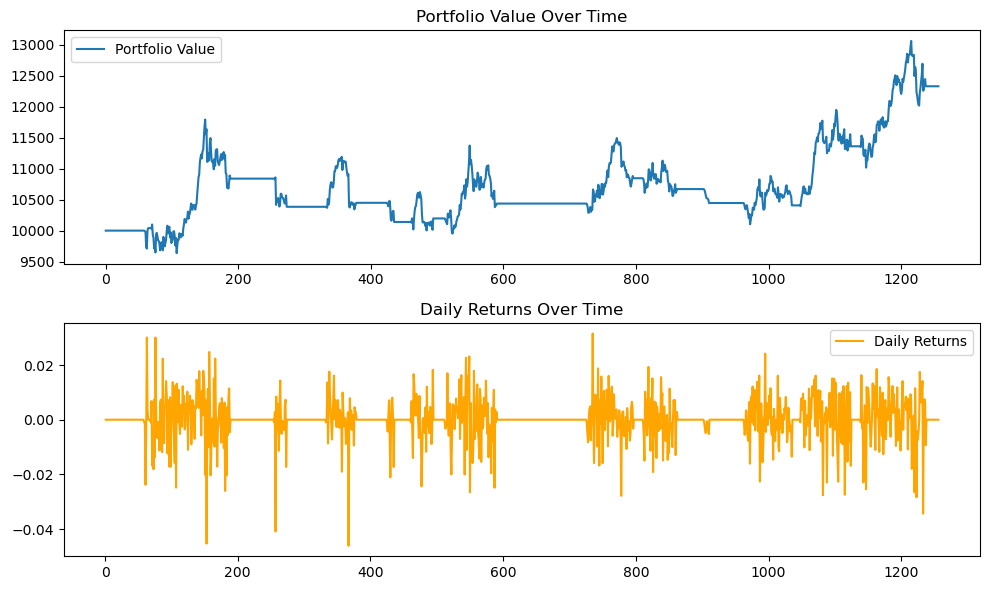

In [34]:
# Define your strategy, indicators, and signal logic here
strategy = Strategy(
    indicators={
        "sma_20": lambda df: df["close"].rolling(window=20).mean(),
        "sma_60": lambda df: df["close"].rolling(window=60).mean(),
    },
    signal_logic=lambda row: 1 if row["sma_20"] > row["sma_60"] else -1,
)

data = strategy.generate_signals(data)
backtester = Backtester()
backtester.backtest(data)
backtester.calculate_performance()

In [38]:
data

,close,sma_20,sma_60,signal,positions
Date,,,,,
2020-01-02,1524.500000,NaN,NaN,-1,0.0
2020-01-03,1549.199951,NaN,NaN,-1,0.0
2020-01-06,1566.199951,NaN,NaN,-1,0.0
2020-01-07,1571.800049,NaN,NaN,-1,0.0
2020-01-08,1557.400024,NaN,NaN,-1,0.0
...,...,...,...,...,...
2024-12-23,2612.300049,2646.894995,2664.685006,-1,0.0
2024-12-24,2620.000000,2647.054993,2664.416671,-1,0.0
2024-12-26,2638.800049,2647.979993,2663.941671,-1,0.0


In [6]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf, pacf, acf

In [14]:
data['GC=F'].values

array([1524.5       , 1549.19995117, 1566.19995117, ..., 2638.80004883,
       2617.19995117, 2606.10009766])

In [17]:
acf(data['GC=F'].pct_change(fill_method=None).dropna().values,nlags=1)

array([ 1.        , -0.01927015])

In [278]:
backtester.assets_data

{'SINGLE_ASSET': {'cash': 0.0,
  'positions': 28.752487010762565,
  'position_value': 13999.01101619308,
  'total_value': 13999.01101619308}}

[*********************100%***********************]  1 of 1 completed

BUY SINGLE_ASSET | Shares: 297.06 | Price: 33.63 | Portfolio: 10000.00
Final Portfolio Value: 11902.13
Total Return: 19.02%
Annualized Return: 19.10%
Annualized Volatility: 13.35%
Sharpe Ratio: 1.28
Sortino Ratio: 1.38
Maximum Drawdown: -7.19%


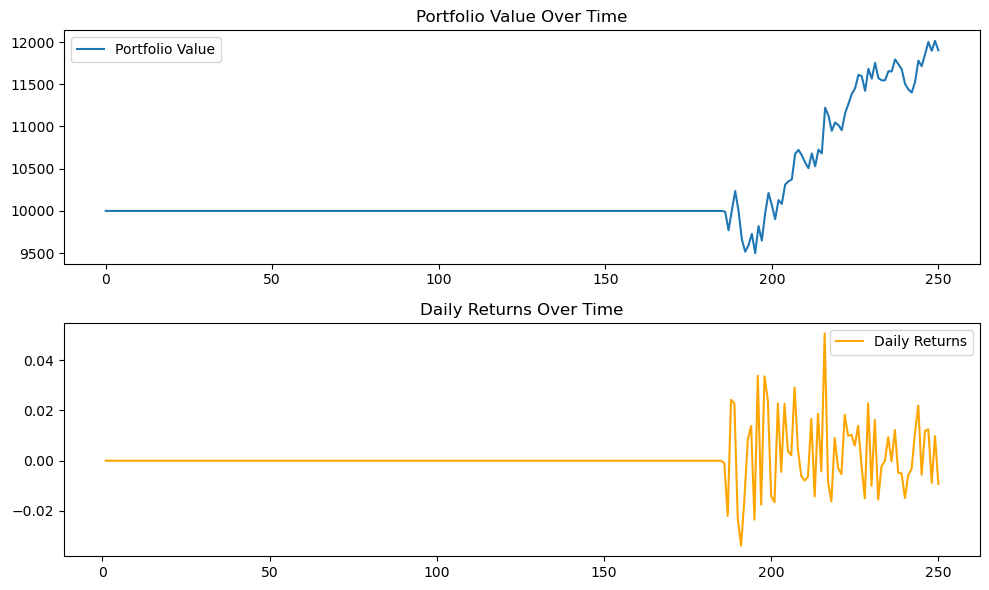

In [218]:
symbol = "HE"
start_date = "2022-01-01"
end_date = "2022-12-31"

data = yf.download(symbol,start=start_date,end=end_date,auto_adjust=True)['Close']
close_name = ['close' for x in data.columns]
data.columns = close_name

# Define your strategy, indicators, and signal logic here


strategy = Strategy(
    indicators={
        "sma_50": lambda df: df["close"].rolling(window=50).mean(),
        "std_3": lambda df: df["sma_50"].std() * 3,
        "std_3_upper": lambda df: df["sma_50"] + df["std_3"],
        "std_3_lower": lambda df: df["sma_50"] - df["std_3"],
    },
    signal_logic=lambda df: (
        1
        if df["close"] < df["std_3_lower"]
        else -1 if df["close"] > df["std_3_upper"] else 0
    ),
)


data = strategy.generate_signals(data)

backtester = Backtester()
backtester.backtest(data)
backtester.calculate_performance()

In [252]:
data

Ticker,close_NFLX,close,day_5_lookback_NFLX,day_5_lookback_ROKU,signal,positions
Date,,,,,,
2023-01-03,294.950012,40.560001,NaN,NaN,0,0.0
2023-01-04,309.410004,42.349998,NaN,NaN,0,0.0
2023-01-05,309.700012,42.759998,NaN,NaN,0,0.0
2023-01-06,315.549988,43.599998,NaN,NaN,0,0.0
2023-01-09,315.170013,45.189999,NaN,NaN,0,0.0
...,...,...,...,...,...,...
2024-03-26,629.239990,64.650002,620.739990,64.540001,0,0.0
2024-03-27,613.530029,65.580002,627.690002,64.949997,0,0.0
2024-03-28,607.330017,65.169998,622.710022,63.830002,0,0.0


In [290]:
tt = data.loc[:,['GC=F']]
tt['Returns'] = tt.pct_change(fill_method=None)
(tt['Returns'].cumsum() > 0).astype(int).mean()

0.9936406995230525

[*********************100%***********************]  2 of 2 completed

BUY SINGLE_ASSET | Shares: 246.30 | Price: 40.56 | Portfolio: 0.00
Final Portfolio Value: 15480.07
Total Return: 54.80%
Annualized Return: 42.16%
Annualized Volatility: 69.70%
Sharpe Ratio: 0.58
Sortino Ratio: 0.96
Maximum Drawdown: -42.20%


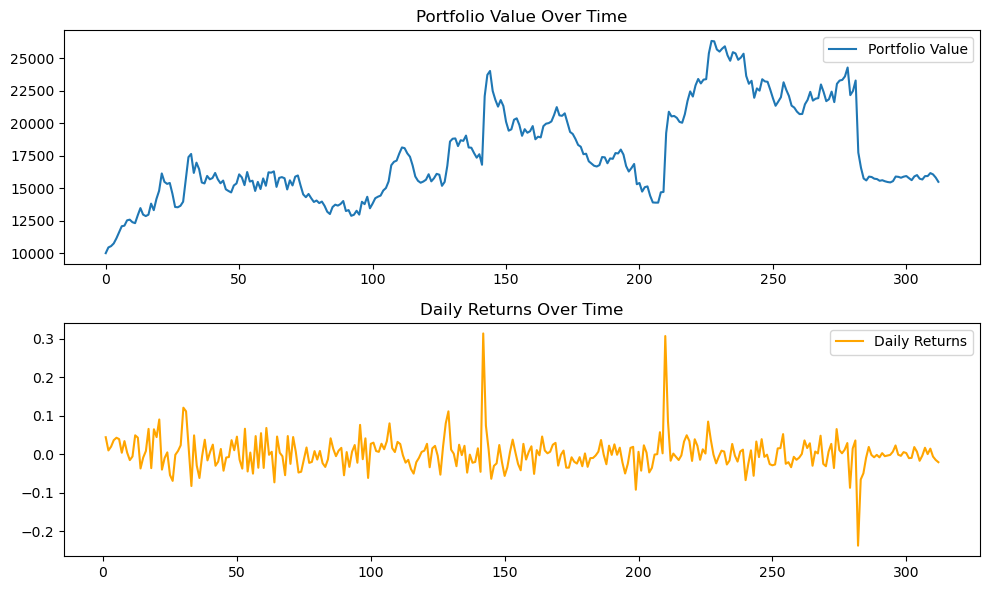

In [260]:
tickers = ["NFLX","ROKU"]
start_date = "2023-01-01"
end_date = "2024-04-03"

data = yf.download(tickers,start=start_date,end=end_date,auto_adjust=True)['Close']


data = data.rename(columns={"NFLX":'close_NFLX','ROKU':'close'})


strategy = Strategy(
    indicators={
        "NFLX_volatility": lambda df: df["close_NFLX"].pct_change().std(),
        "ROKU_volatility": lambda df: df["close"].pct_change().std(),
    },
    signal_logic=lambda row: (
        1
        if (row["NFLX_volatility"] / row["ROKU_volatility"] < .55)
        else -1 if (row["NFLX_volatility"] / row["ROKU_volatility"] > 1.85 ) 
        else 0

    ),
)

#
data = strategy.generate_signals(data)

backtester = Backtester()
backtester.backtest(data)
backtester.calculate_performance()

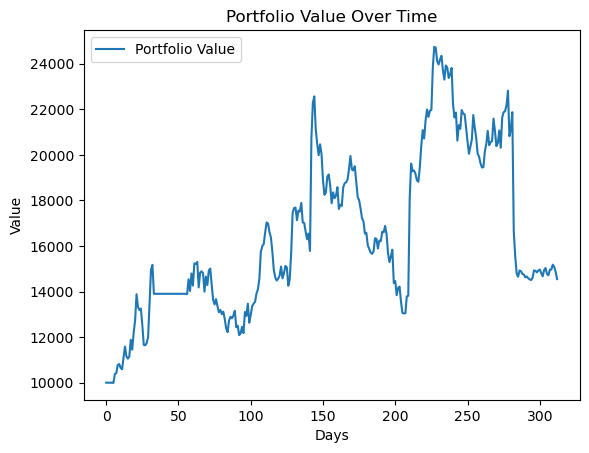

In [222]:
import matplotlib.pyplot as plt
plt.plot(backtester.daily_portfolio_values, label="Portfolio Value")
plt.title("Portfolio Value Over Time")
plt.xlabel("Days")
plt.ylabel("Value")
plt.legend()
plt.show()